# Scaled ZEUS 向量与论文 Table 9

论文来源：[ZEUS，arXiv v2，Table 9](https://arxiv.org/html/2505.10704v2)。本 notebook 只比较 ZEUS 列：本地使用保存的 `embeddings_scaled`，对每个数据集运行种子 `42, 43, 44, 45, 46` 的 K-means，展示五次 ARI × 100 均值。Table 9 也是五种子均值，但未标明具体种子。

下面的表格逐项列出论文值、本地均值、五次运行的标准差，以及“本地 − 论文”。图表使用同一份对照表。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

root = Path.cwd().parent  # 在 notebooks/ 目录启动内核
paper = pd.read_csv(
    root / 'results' / 'zeus_paper_table9.csv',
    usecols=['openml_id', 'paper_zeus'],
).set_index('openml_id')
seeds = (42, 43, 44, 45, 46)
rows = []
for openml_id in paper.index:
    with np.load(root / 'data' / 'embeddings' / f'openml_{openml_id}.npz') as saved:
        embeddings = saved['embeddings_scaled']
        labels = saved['labels']
        n_clusters = len(np.unique(labels))
        for seed in seeds:
            predictions = KMeans(n_clusters=n_clusters, n_init=100, random_state=seed).fit_predict(embeddings)
            rows.append({
                'openml_id': openml_id, 'method': 'scaled_zeus', 'seed': seed,
                'n_clusters': n_clusters, 'n_init': 100,
                'ari': adjusted_rand_score(labels, predictions),
            })

runs = pd.DataFrame(rows)
runs.to_csv(root / 'results' / 'zeus_openml_5seeds.csv', index=False)
local = runs.groupby('openml_id')['ari'].agg(['mean', 'std']) * 100
comparison = paper.join(local.rename(columns={'mean': 'local_zeus', 'std': 'local_std'}))
comparison['delta'] = comparison['local_zeus'] - comparison['paper_zeus']
comparison.to_csv(root / 'results' / 'zeus_table9_comparison.csv', float_format='%.4f')

print(f'{len(comparison)} 个数据集；{len(runs)} 次 K-means；种子：{seeds}')
print(f'ARI × 100 均值：本地 {comparison.local_zeus.mean():.2f}；论文 {comparison.paper_zeus.mean():.2f}')
display(comparison.rename(columns={
    'paper_zeus': 'Paper ZEUS', 'local_zeus': 'Local ZEUS mean',
    'local_std': 'Local std', 'delta': 'Local − paper',
}).round(2))

34 个数据集；170 次 K-means；种子：(42, 43, 44, 45, 46)
ARI × 100 均值：本地 57.36；论文 57.43


,Paper ZEUS,Local ZEUS mean,Local std,Local − paper
openml_id,,,,
14,50.56,50.56,0.00,0.00
15,81.28,81.28,0.00,0.00
16,74.03,74.03,0.00,-0.00
18,51.63,51.62,0.03,-0.01
22,56.05,56.04,0.05,-0.01
35,85.12,85.12,0.00,0.00
51,43.66,43.66,0.00,-0.00
53,35.76,35.76,0.00,0.00
56,66.41,64.19,0.00,-2.22


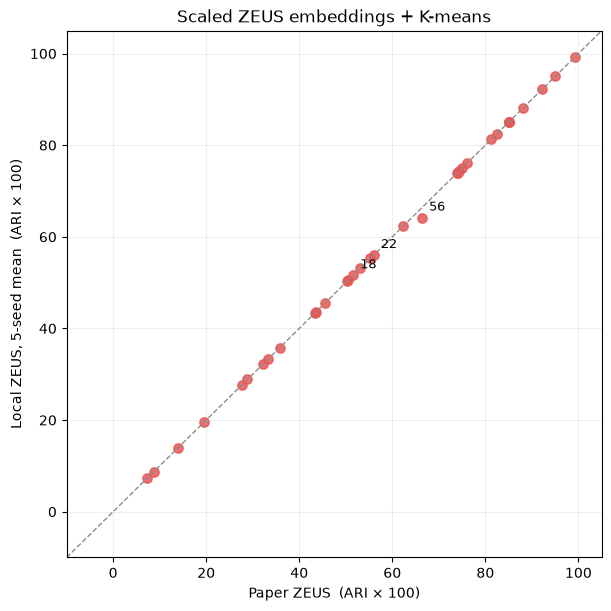

In [2]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
ax.scatter(comparison.paper_zeus, comparison.local_zeus, s=45, color='#e45756', alpha=0.85)
ax.plot([-10, 105], [-10, 105], '--', color='0.55', linewidth=1)
ax.set(xlim=(-10, 105), ylim=(-10, 105),
       xlabel='Paper ZEUS  (ARI × 100)', ylabel='Local ZEUS, 5-seed mean  (ARI × 100)',
       title='Scaled ZEUS embeddings + K-means')
ax.grid(alpha=0.2)
for openml_id in comparison.delta.abs().nlargest(3).index:
    ax.annotate(str(openml_id), (comparison.loc[openml_id, 'paper_zeus'],
                                  comparison.loc[openml_id, 'local_zeus']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
fig.savefig(root / 'results' / 'zeus_table9_scatter.png', dpi=180)
plt.show()

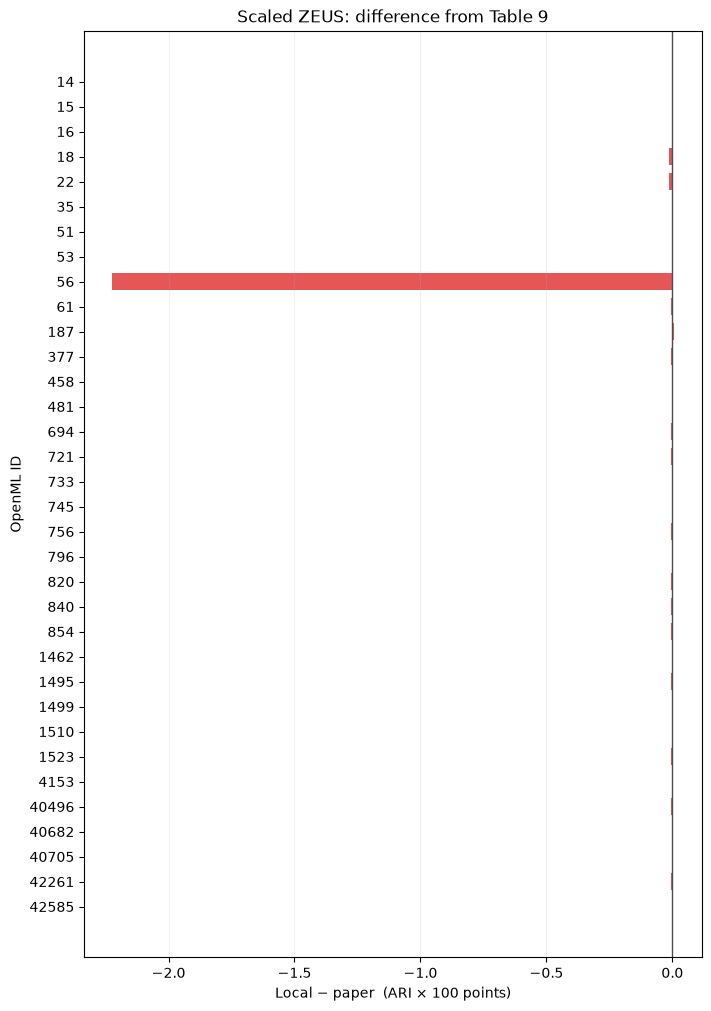

In [3]:
ordered = comparison.sort_index()
fig, ax = plt.subplots(figsize=(7, 10), constrained_layout=True)
ax.barh(ordered.index.astype(str), ordered.delta, color='#e45756', height=0.7)
ax.axvline(0, color='0.3', linewidth=1)
ax.invert_yaxis()
ax.set(xlabel='Local − paper  (ARI × 100 points)', ylabel='OpenML ID',
       title='Scaled ZEUS: difference from Table 9')
ax.grid(axis='x', alpha=0.2)
fig.savefig(root / 'results' / 'zeus_table9_differences.png', dpi=180)
plt.show()